In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb
from sklearn.model_selection import train_test_split

In [4]:
df = pd.read_csv("train.csv")

df["date"] = pd.to_datetime(df["date"])
df["product_id"] = df["store"].astype(str) + "_" + df["item"].astype(str)

df.head()

,date,store,item,sales,product_id
0,2013-01-01,1,1,13,1_1
1,2013-01-02,1,1,11,1_1
2,2013-01-03,1,1,14,1_1
3,2013-01-04,1,1,13,1_1
4,2013-01-05,1,1,10,1_1


In [5]:
df = df.sort_values(["product_id", "date"])

df["lag_1"] = df.groupby("product_id")["sales"].shift(1)
df["lag_7"] = df.groupby("product_id")["sales"].shift(7)
df["lag_14"] = df.groupby("product_id")["sales"].shift(14)

df["rolling_mean_7"] = (
    df.groupby("product_id")["sales"]
    .shift(1)
    .rolling(7)
    .mean()
)

df["day_of_week"] = df["date"].dt.dayofweek

df = df.dropna()

In [6]:
features = [
    "store",
    "item",
    "lag_1",
    "lag_7",
    "lag_14",
    "rolling_mean_7",
    "day_of_week"
]

X = df[features]
y = df["sales"]

In [7]:
lgb_model = lgb.LGBMRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)

lgb_model.fit(X, y)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.026334 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 892
[LightGBM] [Info] Number of data points in the train set: 906000, number of used features: 7
[LightGBM] [Info] Start training from score 52.425825


LGBMRegressor(max_depth=6, n_estimators=200, random_state=42)

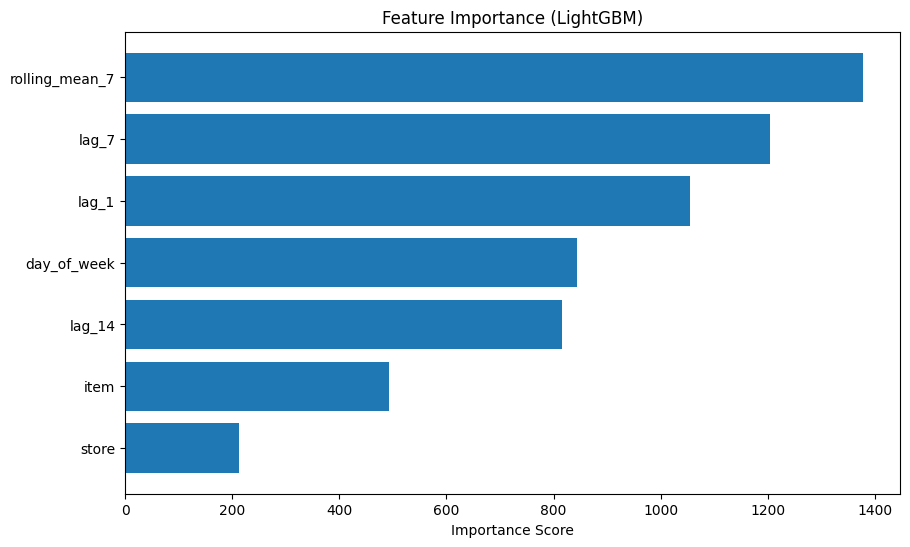

In [8]:
importance = lgb_model.feature_importances_

df_imp = pd.DataFrame({
    "Feature": features,
    "Importance": importance
})

df_imp = df_imp.sort_values("Importance")

plt.figure(figsize=(10,6))

plt.barh(df_imp["Feature"], df_imp["Importance"])

plt.title("Feature Importance (LightGBM)")
plt.xlabel("Importance Score")

plt.show()

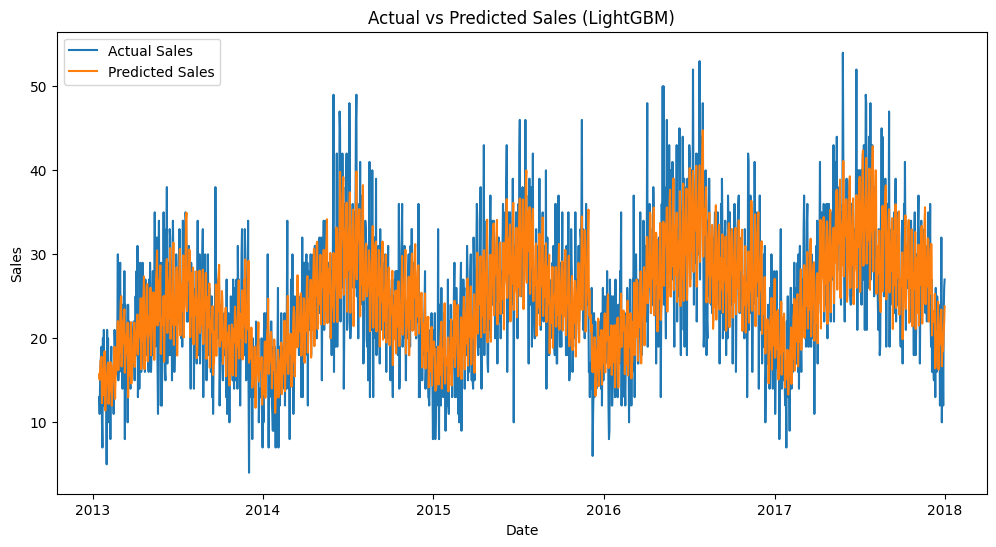

In [9]:
sample_product = df["product_id"].iloc[0]

product_df = df[df["product_id"] == sample_product].sort_values("date")

X_prod = product_df[features]
y_prod = product_df["sales"]

preds = lgb_model.predict(X_prod)

plt.figure(figsize=(12,6))

plt.plot(product_df["date"], y_prod, label="Actual Sales")
plt.plot(product_df["date"], preds, label="Predicted Sales")

plt.title("Actual vs Predicted Sales (LightGBM)")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.legend()

plt.show()

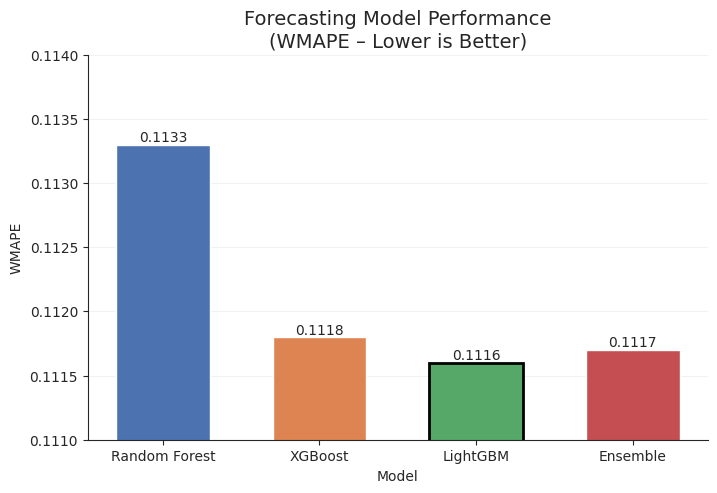

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

models = ["Random Forest","XGBoost","LightGBM","Ensemble"]
wmape_scores = [0.1133,0.1118,0.1116,0.1117]

colors = ["#4C72B0","#DD8452","#55A868","#C44E52"]

sns.set_style("ticks")

plt.figure(figsize=(8,5))

bars = plt.bar(models, wmape_scores, color=colors, width=0.6)

plt.title("Forecasting Model Performance\n(WMAPE – Lower is Better)", fontsize=14)
plt.ylabel("WMAPE")
plt.xlabel("Model")

plt.grid(axis='y', alpha=0.25)

for bar, score in zip(bars, wmape_scores):
    plt.text(
        bar.get_x()+bar.get_width()/2,
        score,
        f"{score:.4f}",
        ha="center",
        va="bottom"
    )

sns.despine()

plt.ylim(0.111, 0.114)
bars[2].set_edgecolor("black")
bars[2].set_linewidth(2)

plt.show()

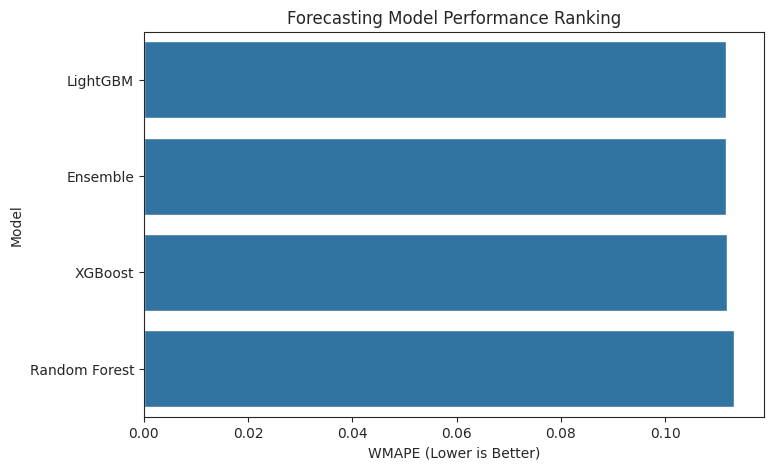

In [11]:
import seaborn as sns
import pandas as pd

data = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost", "LightGBM", "Ensemble"],
    "WMAPE": [0.11329, 0.11179, 0.11165, 0.11168]
})

data = data.sort_values("WMAPE")

plt.figure(figsize=(8,5))

sns.barplot(data=data, x="WMAPE", y="Model")

plt.title("Forecasting Model Performance Ranking")
plt.xlabel("WMAPE (Lower is Better)")

plt.show()

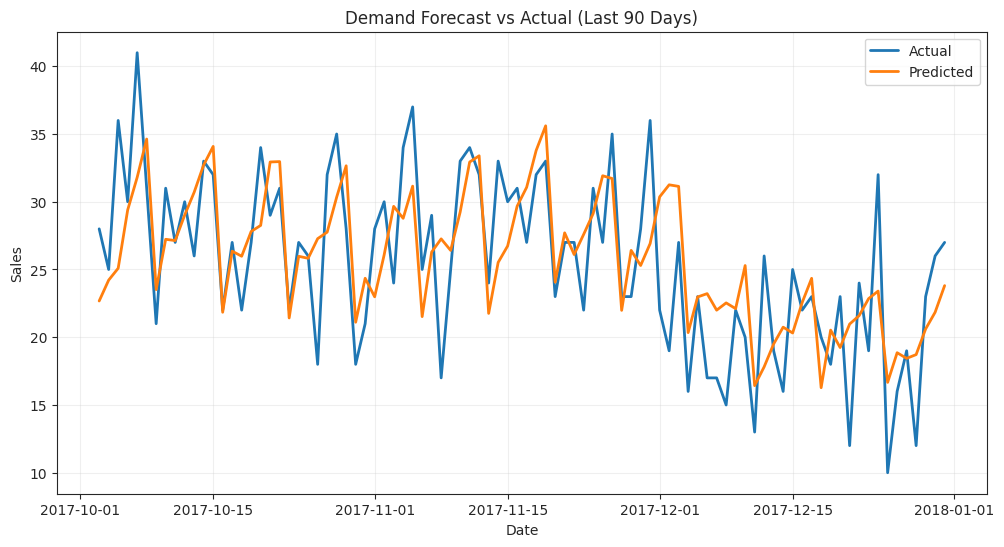

In [12]:
# Select a sample product
sample_product = df["product_id"].iloc[0]

product_df = df[df["product_id"] == sample_product].sort_values("date")

X_prod = product_df[features]
y_prod = product_df["sales"]

preds = lgb_model.predict(X_prod)

# Create dataframe
plot_df = pd.DataFrame({
    "date": product_df["date"],
    "actual": y_prod,
    "predicted": preds
})

# Only show last 90 days
plot_df = plot_df.tail(90)

plt.figure(figsize=(12,6))

plt.plot(plot_df["date"], plot_df["actual"], label="Actual", linewidth=2)
plt.plot(plot_df["date"], plot_df["predicted"], label="Predicted", linewidth=2)

plt.title("Demand Forecast vs Actual (Last 90 Days)")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

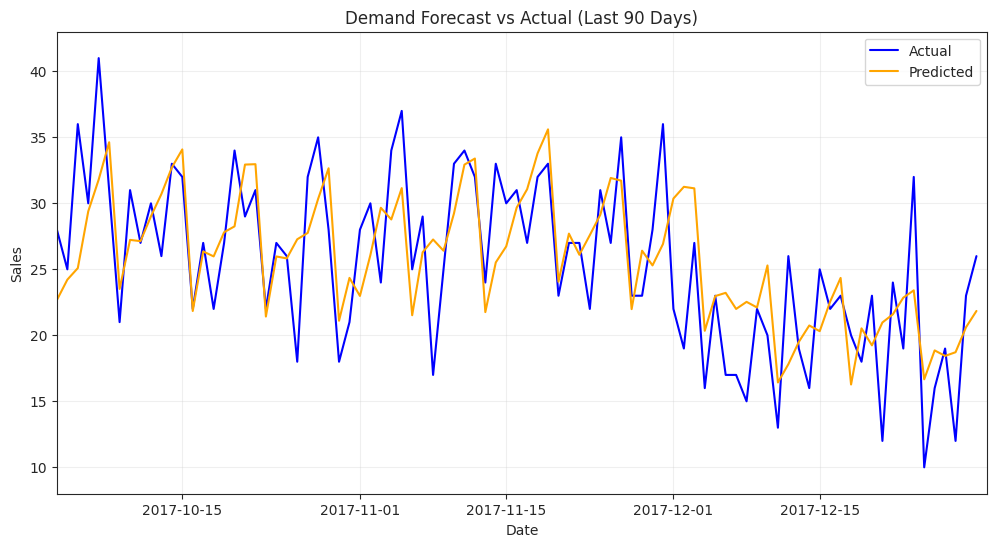

In [13]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12,6))

actual_line, = ax.plot([], [], label="Actual", color="blue")
pred_line, = ax.plot([], [], label="Predicted", color="orange")

ax.set_title("Demand Forecast vs Actual (Last 90 Days)")
ax.set_xlabel("Date")
ax.set_ylabel("Sales")

ax.legend()
ax.grid(alpha=0.3)

dates = plot_df["date"].values
actual = plot_df["actual"].values
pred = plot_df["predicted"].values

ax.set_xlim(dates.min(), dates.max())
ax.set_ylim(min(actual.min(), pred.min())-2, max(actual.max(), pred.max())+2)

def update(frame):
    actual_line.set_data(dates[:frame], actual[:frame])
    pred_line.set_data(dates[:frame], pred[:frame])
    return actual_line, pred_line

ani = FuncAnimation(
    fig,
    update,
    frames=len(dates),
    interval=100,
    blit=True
)

HTML(ani.to_jshtml())

In [14]:
ani.save("forecast_animation.gif", writer="pillow", fps=20)